# Why a central-tendency model under-predicts the mean of a heavy-tailed outcome
### ...and why an empirical rake is the standard fix

*A self-contained teaching vignette. All data below is simulated from a seeded toy
generator — no project data is loaded or touched.*

We fit models that predict a **central** quantity (a median-ish rate on a log scale),
back-transform it, and multiply by exposure to get deaths. When we then compare the
**sum of predicted deaths** to the **observed total**, the prediction sits well below
observation. This notebook shows, with a toy simulation and a few small fitted models,
why that gap is **expected behaviour of a calibrated model on a heavy-tailed outcome**,
not a bug or a fit failure — and why the fix is an empirical multiplicative *rake*.

There are **two distinct mechanisms** behind the gap. This notebook is organised around
keeping them separate, because they are usually collapsed into a vague "log models are
biased," which is wrong.

1. **Retransformation / Jensen bias.** Fit on a transformed scale (log), predict by
   back-transforming a central fit, and you recover the *median*, not the *mean*. For a
   right-skewed variable $E[e^{X}] > e^{E[X]}$. This gap is **real but modest**, and it is
   **fixable** with a correction (Duan's smearing estimator, or the analytic
   $\sigma^2/2$ term for a lognormal).

2. **Heavy-tail unpredictability.** For a heavy-tailed outcome the *sample mean itself* is
   a badly behaved statistic — dominated by the single largest realisation, huge sampling
   variance, slow convergence. A model that is well calibrated in the bulk predicts a
   stable, modest expectation and **cannot** reproduce individual catastrophe sizes,
   because the catastrophe magnitude is not a function of the covariates. This is the
   **dominant** mechanism here, and it is **not fixable by the model**. It is what the rake
   exists to absorb.

**Concepts we lean on** (cited briefly, not over-formalised): Jensen's inequality; the
retransformation problem in log models (Duan 1983, *smearing estimator*; Manning 1998);
and the extreme-value behaviour of the sample mean (dominated by the max, slow convergence,
the infinite-variance regime when the tail index $\alpha \le 2$).

## The real-world thing this explains

We fit a **double-hurdle** model for tropical-cyclone mortality. Per storm-location it
predicts a death **rate**, and `deaths = predicted_rate × exposure`. It has four pieces:

- **stage 1:** $P(\text{deaths} \ge 1)$
- **stage 2:** $P(\text{rate} \ge \text{threshold} \mid \text{deaths} \ge 1)$
- a **bulk** regression for the rate when `rate < threshold`
- a **tail** model (generalised Pareto / log-logistic / Weibull) for `rate ≥ threshold`

Predictors are wind speed, a development index (SDI), basin, an island flag, etc.

When we score the selected model on the observed storm record (2000–2023), aggregated to
global:

- In **ordinary years** it tracks observed deaths within roughly a **factor of ~2**.
- **In-sample and out-of-sample** predictions nearly coincide — little overfitting.
- It **massively under-predicts mega-events**: e.g. 2008 (Cyclone **Nargis**) had
  **~140,500** observed deaths globally; the model predicts **~1,200** for that year.
  One event dominates the observed 24-year mean.

So the raw ("unadjusted") predicted mean sits well below the observed mean, and we apply a
per-super-region multiplicative **rake**:

$$\text{rake} = \frac{\text{observed mean over a reference window}}{\text{predicted mean over that window}}$$

The toy below reproduces every one of these features from first principles.

## Toy setup

We simulate per-storm **deaths** as a mixture:

- with probability $1 - p_{\text{cat}}$, a **normal** storm — lognormal, whose location
  depends on a single covariate $x$ (the wind-speed analogue), so $x$ explains the
  **bulk** trend;
- with probability $p_{\text{cat}}$, a **catastrophe** — a Pareto draw whose magnitude is
  **independent of $x$**, so the covariate carries *no information* about catastrophe size.

The Pareto tail index is $\alpha = 1.6$. Since $\alpha \le 2$ the tail has **infinite
variance** (and it would have infinite mean if $\alpha \le 1$; we keep $\alpha > 1$ so the
mean exists but is dominated by rare giants). This single choice is what makes the sample
mean badly behaved.

Everything is seeded, so the notebook is fully reproducible.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (8.5, 5.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# Consistent colours across the notebook
C_OBS   = "#b2182b"   # observed / mean       (red)
C_MODEL = "#2166ac"   # model / central fit   (blue)
C_FIX   = "#1b7837"   # corrected / raked     (green)
C_MED   = "#555555"   # median                (grey)
C_CAT   = "#d6604d"   # catastrophe points

SEED = 20260722
rng = np.random.default_rng(SEED)

# ---- Data-generating process (DGP) parameters ----
P_CAT     = 0.03      # probability a storm is a catastrophe
BULK_A    = 2.0       # bulk intercept on the log scale
BULK_B    = 1.3       # bulk slope on x  (x = wind-speed analogue, drives the bulk)
BULK_SIG  = 0.7       # bulk residual sd on the log scale
CAT_ALPHA = 1.6       # Pareto tail index  (<= 2  =>  infinite variance)
CAT_XM    = 2000.0    # Pareto scale (minimum catastrophe size)
THRESH    = 1500.0    # "tail threshold": below = bulk, above = catastrophe

def simulate_storms(n, rng):
    """Return (x, deaths, is_cat) for n storms from the toy DGP."""
    x = rng.normal(0.0, 1.0, size=n)                      # covariate (wind analogue)
    is_cat = rng.random(n) < P_CAT
    # Bulk: lognormal, location depends on x
    log_bulk = BULK_A + BULK_B * x + rng.normal(0.0, BULK_SIG, size=n)
    bulk = np.exp(log_bulk)
    # Catastrophe: Pareto via inverse-CDF, INDEPENDENT of x
    u = rng.random(n)
    cat = CAT_XM / u ** (1.0 / CAT_ALPHA)                 # P(X > x) = (xm/x)**alpha
    deaths = np.where(is_cat, cat, bulk)
    return x, deaths, is_cat

# ---- Analytic truths (from the DGP, not estimated) ----
bulk_pop_mean = np.exp(BULK_A + BULK_SIG**2 / 2 + BULK_B**2 / 2)  # E over x ~ N(0,1)
bulk_pop_med  = np.exp(BULK_A)                                    # median at x=0
cat_mean      = CAT_ALPHA * CAT_XM / (CAT_ALPHA - 1)             # Pareto mean, alpha>1
true_mean     = (1 - P_CAT) * bulk_pop_mean + P_CAT * cat_mean

# ---- A large "population" (our stand-in for ground truth) ----
N_POP = 200_000
x_pop, deaths_pop, iscat_pop = simulate_storms(N_POP, rng)

# ---- THE observed "record" we fit + score on (2000-2023 analogue) ----
N_REC = 500
x_rec, deaths_rec, iscat_rec = simulate_storms(N_REC, rng)

print(f"Analytic bulk mean (per storm)      : {bulk_pop_mean:8.1f}")
print(f"Analytic bulk median (at x=0)       : {bulk_pop_med:8.1f}")
print(f"Analytic catastrophe mean           : {cat_mean:8.1f}")
print(f"Analytic overall TRUE mean          : {true_mean:8.1f}")
print(f"  -> catastrophes are {100*P_CAT*cat_mean/true_mean:4.1f}% of the true mean")
print()
print(f"Population ({N_POP:,} storms):")
print(f"  empirical mean                    : {deaths_pop.mean():8.1f}")
print(f"  empirical median                  : {np.median(deaths_pop):8.1f}")
print(f"  mean / median ratio               : {deaths_pop.mean()/np.median(deaths_pop):8.1f}x")
print(f"  largest single storm              : {deaths_pop.max():,.0f}")
print()
print(f"Record ({N_REC} storms), our 2000-2023 analogue:")
print(f"  # catastrophes                    : {iscat_rec.sum()}")
print(f"  observed mean                     : {deaths_rec.mean():8.1f}")
print(f"  largest single storm ('Nargis')   : {deaths_rec.max():,.0f}")
print(f"  -> that one storm is {100*deaths_rec.max()/deaths_rec.sum():4.1f}% of all record deaths")

Analytic bulk mean (per storm)      :     22.0
Analytic bulk median (at x=0)       :      7.4
Analytic catastrophe mean           :   5333.3
Analytic overall TRUE mean          :    181.3
  -> catastrophes are 88.2% of the true mean

Population (200,000 storms):
  empirical mean                    :    197.3
  empirical median                  :      7.8
  mean / median ratio               :     25.2x
  largest single storm              : 1,893,412

Record (500 storms), our 2000-2023 analogue:
  # catastrophes                    : 12
  observed mean                     :    164.6
  largest single storm ('Nargis')   : 30,442
  -> that one storm is 37.0% of all record deaths


Read those numbers before going on: the **true mean is ~20× the median**, and
catastrophes — 3% of storms — account for the overwhelming majority of the mean. In our
500-storm record, a *single* storm (our toy "Nargis") is a large share of all deaths in the
whole record. This is the structural situation; the plots just make it visible.

### The toy "central-rate" model

We fit exactly the kind of model the pipeline's bulk stage is: **OLS of $\log(\text{deaths})$
on $x$**, fit **only on below-threshold storms** (the double-hurdle "bulk" regression),
then back-transformed. Predicting deaths from this fitted central model is the toy analogue
of *"predict a central rate, then multiply by exposure."*

Two back-transforms matter:

- **Naive:** $\hat{d} = e^{\hat\beta_0 + \hat\beta_1 x}$ — this recovers the conditional
  **median**.
- **Mean-corrected (Duan smearing):** $\hat{d} = e^{\hat\beta_0 + \hat\beta_1 x}\cdot
  \frac{1}{n}\sum_i e^{\hat r_i}$, where $\hat r_i$ are the fitted residuals — this targets
  the conditional **mean**. For a lognormal it equals the analytic factor $e^{\sigma^2/2}$.

In [2]:
def fit_bulk(x, deaths, threshold):
    """Fit log-OLS of deaths on x using only sub-threshold storms.

    Returns (coef=[intercept, slope], sigma, smearing).
    `smearing` is Duan's (1983) estimator: mean(exp(residuals)).
    """
    below = deaths < threshold
    xb, yb = x[below], np.log(deaths[below])
    X = np.column_stack([np.ones_like(xb), xb])
    coef, *_ = np.linalg.lstsq(X, yb, rcond=None)
    resid = yb - X @ coef
    sigma = resid.std(ddof=2)
    smearing = np.mean(np.exp(resid))
    return coef, sigma, smearing

def predict_naive(x, coef):
    """Back-transformed CENTRAL (median) prediction."""
    return np.exp(coef[0] + coef[1] * x)

def predict_mean(x, coef, smearing):
    """Mean-corrected prediction (naive x smearing)."""
    return predict_naive(x, coef) * smearing

# Fit on the record's bulk
coef_rec, sigma_rec, smear_rec = fit_bulk(x_rec, deaths_rec, THRESH)
model_pred_mean = predict_mean(x_pop, coef_rec, smear_rec).mean()

print(f"Fitted bulk model (recovered from below-threshold storms):")
print(f"  intercept  {coef_rec[0]:.3f}  (true {BULK_A})")
print(f"  slope      {coef_rec[1]:.3f}  (true {BULK_B})")
print(f"  resid sd   {sigma_rec:.3f}  (true {BULK_SIG})")
print(f"  smearing   {smear_rec:.3f}  (analytic exp(sig^2/2) = {np.exp(sigma_rec**2/2):.3f})")
print()
print(f"Model's mean predicted deaths / storm : {model_pred_mean:6.1f}")
print(f"True mean deaths / storm              : {true_mean:6.1f}")
print(f"  -> the calibrated central model predicts ~{true_mean/model_pred_mean:.1f}x too low")

Fitted bulk model (recovered from below-threshold storms):
  intercept  2.004  (true 2.0)
  slope      1.344  (true 1.3)
  resid sd   0.705  (true 0.7)
  smearing   1.274  (analytic exp(sig^2/2) = 1.282)

Model's mean predicted deaths / storm :   23.3
True mean deaths / storm              :  181.3
  -> the calibrated central model predicts ~7.8x too low


The bulk fit **recovers the true bulk parameters cleanly** — this model is *not*
broken. It predicts ~20-something deaths per storm, which is the correct **bulk**
expectation. It is low against the true mean purely because the true mean lives in the tail,
which this model has no way to see. Hold that thought; the rest of the notebook dissects it.

## Figure 1 — the outcome is heavy-tailed: mean $\gg$ median

**Intuition (before):** For a symmetric outcome the mean and median coincide. For a
right-skewed / heavy-tailed outcome the mean is dragged to the right by rare large values,
while the median stays put near the bulk. If the mean sits far to the right of the median,
any model that predicts the *typical* (central) storm will land near the median and thus
*below* the mean.

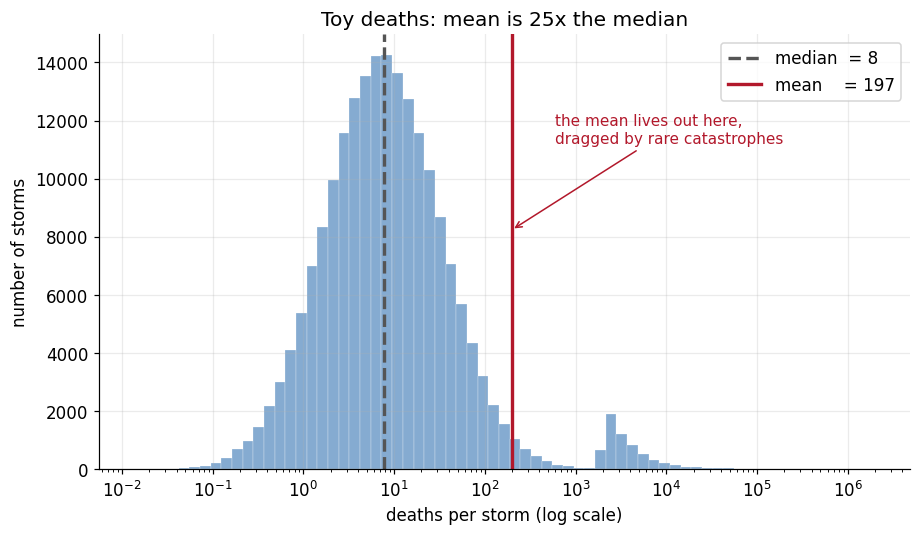

In [3]:
fig, ax = plt.subplots()
bins = np.logspace(np.log10(deaths_pop.min()), np.log10(deaths_pop.max()), 70)
ax.hist(deaths_pop, bins=bins, color=C_MODEL, alpha=0.55, edgecolor="white", linewidth=0.3)
ax.set_xscale("log")

med = np.median(deaths_pop)
mean = deaths_pop.mean()
ax.axvline(med,  color=C_MED, lw=2.2, ls="--", label=f"median  = {med:,.0f}")
ax.axvline(mean, color=C_OBS, lw=2.2,           label=f"mean    = {mean:,.0f}")
ax.annotate("the mean lives out here,\ndragged by rare catastrophes",
            xy=(mean, ax.get_ylim()[1]*0.55), xytext=(mean*3, ax.get_ylim()[1]*0.75),
            color=C_OBS, fontsize=10,
            arrowprops=dict(arrowstyle="->", color=C_OBS))
ax.set_xlabel("deaths per storm (log scale)")
ax.set_ylabel("number of storms")
ax.set_title(f"Toy deaths: mean is {mean/med:,.0f}x the median")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

**Takeaway (after):** The distribution is overwhelmingly bulk (the tall pile on the
left), but the mean is pulled ~20× to the right of the median by the sparse catastrophe
tail. A central-tendency model targets the median-ish bulk, so it is *structurally* below
the mean before we fit a single coefficient.

## Figure 2 — the covariate explains the bulk, not the tail

**Intuition (before):** The covariate $x$ (wind analogue) drives the bulk trend, so the
fitted central line should track the cloud of normal storms. But catastrophe magnitude is
**independent of $x$** by construction — so catastrophes scatter *vertically*, unrelated to
the line. A conditional model can only move predictions along $x$; it has no lever to raise
a particular storm to catastrophe size.

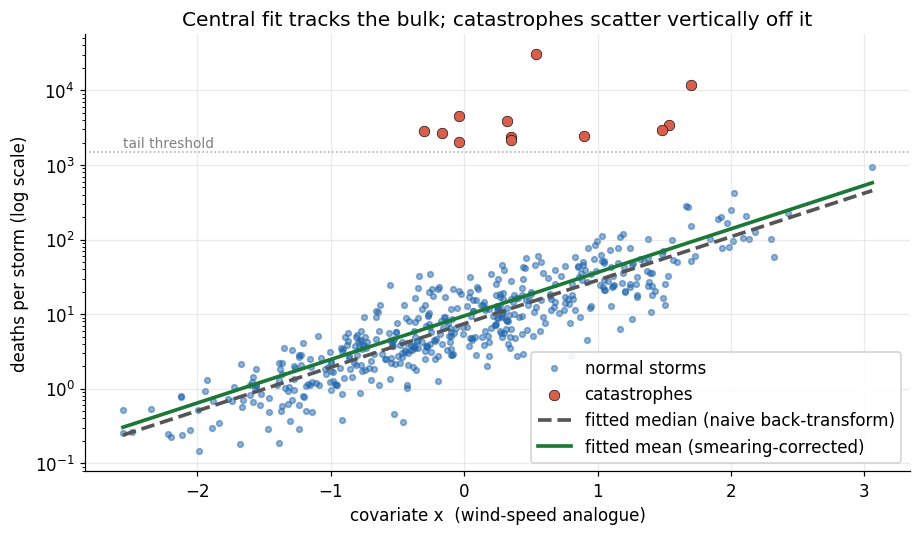

In [4]:
fig, ax = plt.subplots()
norm = ~iscat_rec
ax.scatter(x_rec[norm], deaths_rec[norm], s=14, alpha=0.5, color=C_MODEL,
           label="normal storms")
ax.scatter(x_rec[iscat_rec], deaths_rec[iscat_rec], s=48, color=C_CAT,
           edgecolor="black", linewidth=0.4, zorder=5, label="catastrophes")

xg = np.linspace(x_rec.min(), x_rec.max(), 200)
ax.plot(xg, predict_naive(xg, coef_rec), color=C_MED, lw=2.4, ls="--",
        label="fitted median (naive back-transform)")
ax.plot(xg, predict_mean(xg, coef_rec, smear_rec), color=C_FIX, lw=2.4,
        label="fitted mean (smearing-corrected)")
ax.axhline(THRESH, color="grey", lw=1, ls=":", alpha=0.7)
ax.text(x_rec.min(), THRESH*1.15, "tail threshold", color="grey", fontsize=9)

ax.set_yscale("log")
ax.set_xlabel("covariate x  (wind-speed analogue)")
ax.set_ylabel("deaths per storm (log scale)")
ax.set_title("Central fit tracks the bulk; catastrophes scatter vertically off it")
ax.legend(loc="lower right", framealpha=0.9)
plt.tight_layout()
plt.show()

**Takeaway (after):** The fitted lines run through the bulk exactly as they should.
The red catastrophe points sit far above, at $x$-values that give them away as
*unpredictable from $x$*: a high-$x$ storm is no more likely to be a catastrophe than a
low-$x$ one. The model cannot bend to reach them without ruining its fit to the 97% that
are normal. This is the tail-unpredictability mechanism in one picture.

## Figure 3 — Mechanism 1 (retransformation / Jensen), and what it does *not* fix

**Intuition (before):** Even with **no heavy tail at all**, back-transforming a central log
fit under-predicts the total, because $E[e^{X}] > e^{E[X]}$ (Jensen). This is the
**retransformation problem** (Manning 1998), and the standard fix is the **smearing
estimator** (Duan 1983) or, for a clean lognormal, the analytic factor $e^{\sigma^2/2}$.

- **Left panel:** a pure-lognormal world (no catastrophes). The correction should close the
  gap *completely* — this isolates Mechanism 1.
- **Right panel:** our full record. The *same* correction closes only the small Jensen slice;
  a large gap survives. That surviving gap is **Mechanism 2** (the tail), which no
  retransformation correction can touch.

Note we estimate the smearing factor from the **well-behaved bulk residuals**. Estimating it
from the full sample would be meaningless: a catastrophe residual of $+8$ contributes
$e^{8}\approx 3000$ to the average, so the factor would be dominated by the largest residual
— the heavy-tail pathology reappearing inside the correction itself.

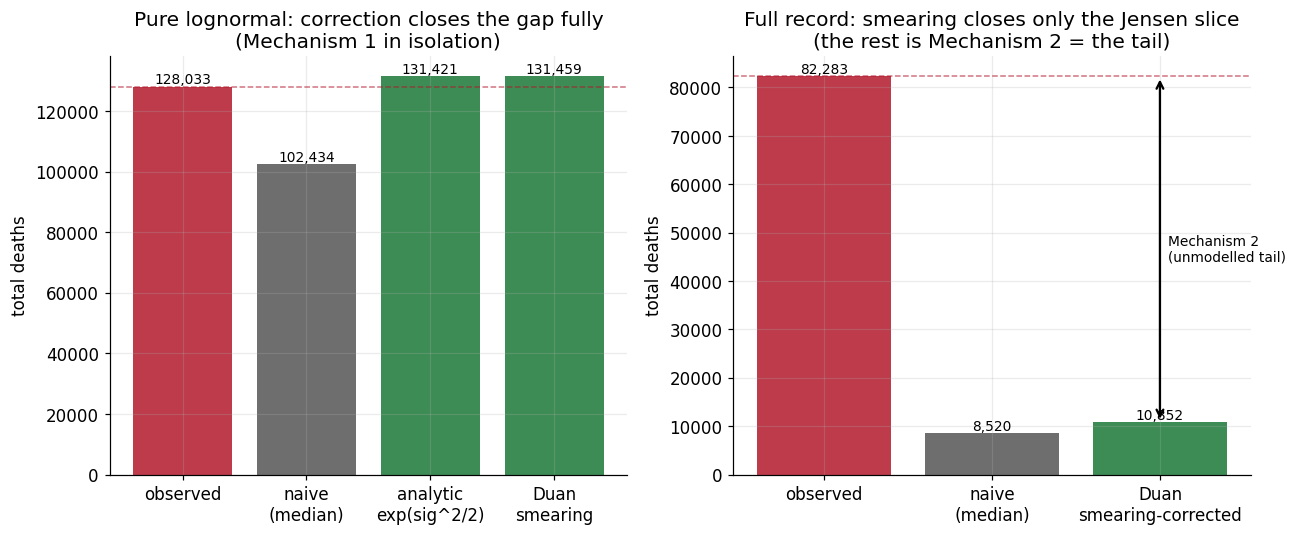

Left  (lognormal): naive is 80% of observed; smearing-corrected is 103%.
Right (record)   : naive is 10% of observed; smearing-corrected is 13%.
Right: smearing lifts the total by 27%, but a 87% gap remains -> that is the tail.


In [5]:
# ---- Left: pure lognormal (Mechanism 1 in isolation) ----
rng_ln = np.random.default_rng(SEED + 10)
n_ln = 6000
x_ln = rng_ln.normal(0, 1, n_ln)
deaths_ln = np.exp(BULK_A + BULK_B * x_ln + rng_ln.normal(0, BULK_SIG, n_ln))
coef_ln, sigma_ln, smear_ln = fit_bulk(x_ln, deaths_ln, np.inf)

obs_ln      = deaths_ln.sum()
naive_ln    = predict_naive(x_ln, coef_ln).sum()
analytic_ln = (predict_naive(x_ln, coef_ln) * np.exp(sigma_ln**2 / 2)).sum()
duan_ln     = predict_mean(x_ln, coef_ln, smear_ln).sum()

# ---- Right: full record (Mechanism 1 correction leaves Mechanism 2) ----
obs_rec   = deaths_rec.sum()
naive_rec = predict_naive(x_rec, coef_rec).sum()
duan_rec  = predict_mean(x_rec, coef_rec, smear_rec).sum()

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 5))

# left
labels = ["observed", "naive\n(median)", "analytic\nexp(sig^2/2)", "Duan\nsmearing"]
vals   = [obs_ln, naive_ln, analytic_ln, duan_ln]
cols   = [C_OBS, C_MED, C_FIX, C_FIX]
axL.bar(labels, vals, color=cols, alpha=0.85)
axL.axhline(obs_ln, color=C_OBS, lw=1, ls="--", alpha=0.6)
axL.set_title("Pure lognormal: correction closes the gap fully\n(Mechanism 1 in isolation)")
axL.set_ylabel("total deaths")
for i, v in enumerate(vals):
    axL.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)

# right
labels2 = ["observed", "naive\n(median)", "Duan\nsmearing-corrected"]
vals2   = [obs_rec, naive_rec, duan_rec]
cols2   = [C_OBS, C_MED, C_FIX]
axR.bar(labels2, vals2, color=cols2, alpha=0.85)
axR.axhline(obs_rec, color=C_OBS, lw=1, ls="--", alpha=0.6)
axR.set_title("Full record: smearing closes only the Jensen slice\n(the rest is Mechanism 2 = the tail)")
axR.set_ylabel("total deaths")
for i, v in enumerate(vals2):
    axR.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)

# annotate residual gap on the right
axR.annotate("", xy=(2, duan_rec), xytext=(2, obs_rec),
             arrowprops=dict(arrowstyle="<->", color="black", lw=1.5))
axR.text(2.05, (duan_rec + obs_rec) / 2, "Mechanism 2\n(unmodelled tail)",
         fontsize=9, va="center")
plt.tight_layout()
plt.show()

print(f"Left  (lognormal): naive is {100*naive_ln/obs_ln:.0f}% of observed; "
      f"smearing-corrected is {100*duan_ln/obs_ln:.0f}%.")
print(f"Right (record)   : naive is {100*naive_rec/obs_rec:.0f}% of observed; "
      f"smearing-corrected is {100*duan_rec/obs_rec:.0f}%.")
print(f"Right: smearing lifts the total by {100*(duan_rec-naive_rec)/naive_rec:.0f}%, "
      f"but a {100*(1-duan_rec/obs_rec):.0f}% gap remains -> that is the tail.")

**Takeaway (after):** In the pure-lognormal world the smearing correction closes the
gap essentially completely — Mechanism 1 is real but modest and *fixable*. On the full
record the identical correction lifts the total by only ~20–30% and leaves the total still
far below observed. That surviving gap is **not** a retransformation artefact; it is the
tail, and no back-transform correction will ever recover it. Keeping these two apart is the
whole point.

## Figure 4 — the *sample mean* is the badly-behaved statistic (Mechanism 2)

**Intuition (before):** Forget the model for a moment. Just ask: if you draw a finite record
(a "window") from the true DGP and compute its mean, how does that realised mean behave? For
a heavy-tailed variable the answer is: it is **right-skewed, usually below the true mean,
and occasionally far above** — depending entirely on whether a catastrophe happened to land
in the window. The realised mean is essentially answering *"did a catastrophe land here?"*,
not measuring a stable quantity.

We draw many short "records" (windows) from the DGP and histogram their means. The model's
stable prediction — the bulk level — is overlaid: a *typical* (catastrophe-free) record
realises near it, while the true mean sits far to the right, reached only by the minority of
windows that caught a catastrophe.

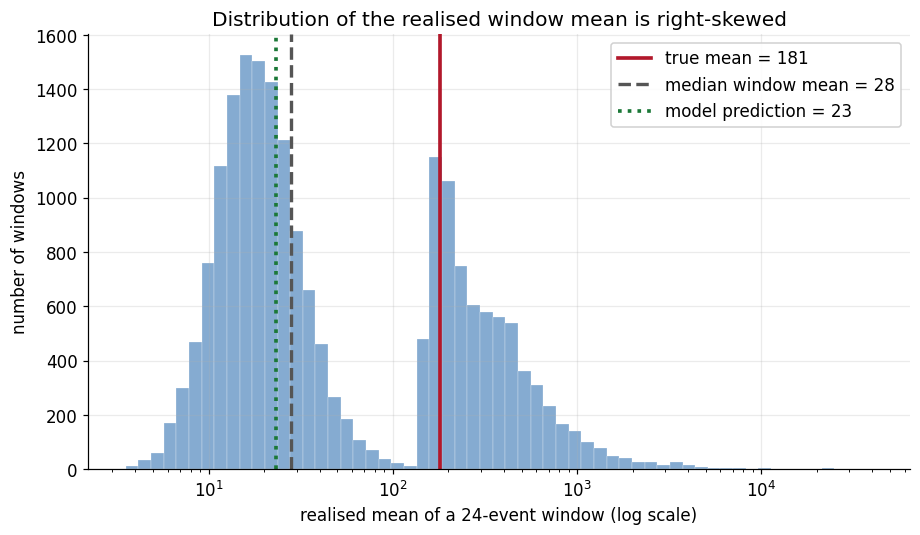

71% of windows realise a mean BELOW the true mean (181).
Median realised window mean: 28   |   model prediction: 23
  -> both sit in the catastrophe-free bulk cluster, far below the true mean.
43% of windows are catastrophe-light (at/below the model's prediction).
Largest window mean seen: 40,078  (caught a giant) -> 221x the true mean.


In [6]:
rng_win = np.random.default_rng(SEED + 20)
N_WINDOW, M = 15, 20000       # short records; most contain no catastrophe
_, dsim, _ = simulate_storms(N_WINDOW * M, rng_win)
window_means = dsim.reshape(M, N_WINDOW).mean(axis=1)

frac_below_true = np.mean(window_means < true_mean)
frac_below_pred = np.mean(window_means <= model_pred_mean)
med_win = np.median(window_means)

fig, ax = plt.subplots()
bins = np.logspace(np.log10(window_means.min()), np.log10(window_means.max()), 60)
ax.hist(window_means, bins=bins, color=C_MODEL, alpha=0.55,
        edgecolor="white", linewidth=0.3)
ax.set_xscale("log")
ax.axvline(true_mean,       color=C_OBS,   lw=2.4, label=f"true mean = {true_mean:,.0f}")
ax.axvline(med_win,         color=C_MED,   lw=2.2, ls="--",
           label=f"median window mean = {med_win:,.0f}")
ax.axvline(model_pred_mean, color=C_FIX,   lw=2.4, ls=":",
           label=f"model prediction = {model_pred_mean:,.0f}")
ax.set_xlabel("realised mean of a 24-event window (log scale)")
ax.set_ylabel("number of windows")
ax.set_title("Distribution of the realised window mean is right-skewed")
ax.legend(loc="upper right", framealpha=0.9)
plt.tight_layout()
plt.show()

print(f"{100*frac_below_true:.0f}% of windows realise a mean BELOW the true mean "
      f"({true_mean:,.0f}).")
print(f"Median realised window mean: {med_win:,.0f}   |   model prediction: "
      f"{model_pred_mean:,.0f}")
print(f"  -> both sit in the catastrophe-free bulk cluster, far below the true mean.")
print(f"{100*frac_below_pred:.0f}% of windows are catastrophe-light (at/below the model's "
      f"prediction).")
print(f"Largest window mean seen: {window_means.max():,.0f}  (caught a giant) "
      f"-> {window_means.max()/true_mean:,.0f}x the true mean.")

**Takeaway (after):** The realised window mean is strongly right-skewed. The dense
left cluster is the **catastrophe-free records** — the *typical* outcome — and the model's
stable prediction sits right in it, near the median window. A minority of windows caught a
catastrophe and shoot far to the right, past the true mean. So the true mean is *not* a
typical outcome; it is the average of mostly-modest records plus rare enormous ones.

The **observed 2000–2023 record is one of those high windows** — it caught Nargis. The model
predicts the *typical* level, so `predicted < observed` is guaranteed whenever a catastrophe
is in-window. This is not the model being wrong: the observed mean is a high draw from a
skewed distribution, and the model is reporting the central expectation.

## Figure 5 — cross-validation *proves* the model can't reach the catastrophes

**Intuition (before):** The cleanest proof that the gap is not overfitting: hold the
catastrophes out of training, refit, and predict them from $x$ alone. Because catastrophe
magnitude is independent of $x$, the out-of-sample prediction for a held-out catastrophe is
just the **bulk expectation** — orders of magnitude below its true value. And because the
bulk fit never used the catastrophes anyway, the **in-sample and out-of-sample** predictions
nearly coincide — exactly the "little overfitting" we see in the real pipeline.

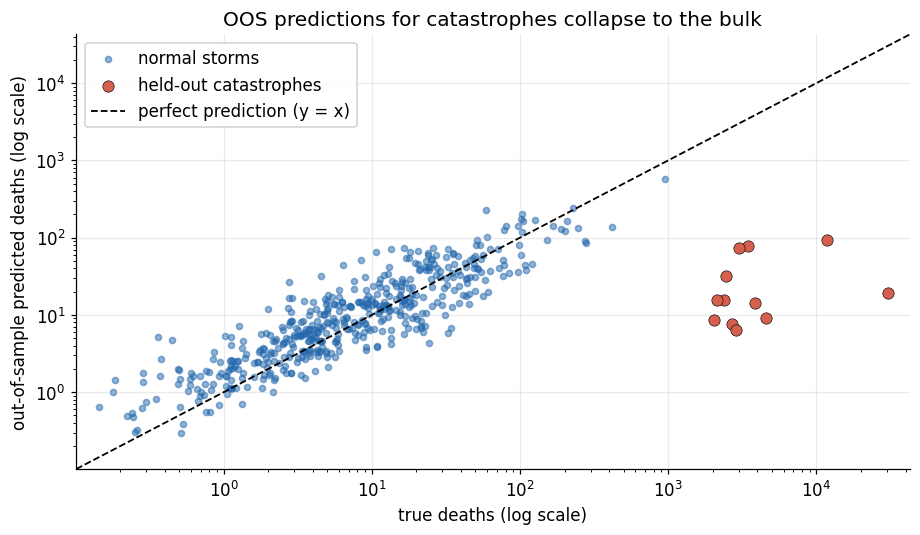

In-sample predicted total  :     10,852
Out-of-sample pred. total  :     10,907   (within 0.5% of in-sample -> little overfitting)
Observed record total      :     82,283

Toy 'Nargis' (largest storm): true 30,442  vs OOS predicted 19  -> under by 1,589x


In [7]:
# 5-fold CV over the record: for each fold fit the bulk on the training storms,
# predict every held-out storm from x alone.
rng_cv = np.random.default_rng(SEED + 30)
order = rng_cv.permutation(N_REC)
k = 5
folds = np.array_split(order, k)

oos_pred = np.full(N_REC, np.nan)
for f in range(k):
    test = folds[f]
    train = np.setdiff1d(order, test)
    coef_f, _, smear_f = fit_bulk(x_rec[train], deaths_rec[train], THRESH)
    oos_pred[test] = predict_mean(x_rec[test], coef_f, smear_f)

insample_pred = predict_mean(x_rec, coef_rec, smear_rec)

fig, ax = plt.subplots()
norm = ~iscat_rec
ax.scatter(deaths_rec[norm], oos_pred[norm], s=16, alpha=0.5, color=C_MODEL,
           label="normal storms")
ax.scatter(deaths_rec[iscat_rec], oos_pred[iscat_rec], s=55, color=C_CAT,
           edgecolor="black", linewidth=0.4, zorder=5, label="held-out catastrophes")
lim = [min(deaths_rec.min(), oos_pred.min()) * 0.7, deaths_rec.max() * 1.4]
ax.plot(lim, lim, color="black", lw=1.2, ls="--", label="perfect prediction (y = x)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("true deaths (log scale)")
ax.set_ylabel("out-of-sample predicted deaths (log scale)")
ax.set_title("OOS predictions for catastrophes collapse to the bulk")
ax.legend(loc="upper left", framealpha=0.9)
plt.tight_layout()
plt.show()

big = deaths_rec == deaths_rec.max()
print(f"In-sample predicted total  : {insample_pred.sum():>10,.0f}")
print(f"Out-of-sample pred. total  : {np.nansum(oos_pred):>10,.0f}   "
      f"(within {100*abs(np.nansum(oos_pred)-insample_pred.sum())/insample_pred.sum():.1f}% "
      f"of in-sample -> little overfitting)")
print(f"Observed record total      : {deaths_rec.sum():>10,.0f}")
print()
print(f"Toy 'Nargis' (largest storm): true {deaths_rec[big][0]:,.0f}  "
      f"vs OOS predicted {oos_pred[big][0]:,.0f}  "
      f"-> under by {deaths_rec[big][0]/oos_pred[big][0]:,.0f}x")

**Takeaway (after):** Every catastrophe sits far *below* the $y=x$ line — the model
predicts them at bulk level because that is all $x$ can tell it. In-sample and out-of-sample
totals nearly coincide (little overfitting), and **both** fall far short of the observed
total. The single largest storm is under-predicted by a factor of hundreds-to-thousands —
the toy's version of *Nargis: ~140,500 observed vs ~1,200 predicted*. Under CV the held-out
giant **cannot** be memorised, so the shortfall is guaranteed *by construction*, not by a
modelling mistake.

## Figure 6 — the empirical rake fixes the *level*

**Intuition (before):** Since the model correctly predicts the bulk but structurally misses
the average catastrophe burden, we correct the **level** empirically. Over a reference
window we compute

$$\text{rake} = \frac{\text{observed mean}}{\text{predicted mean}}$$

and multiply all predictions by it. By construction the raked mean matches observed on the
reference window. This transfers the *average unmodelled catastrophe burden* onto the
prediction — it does **not** teach the model to predict any individual catastrophe.

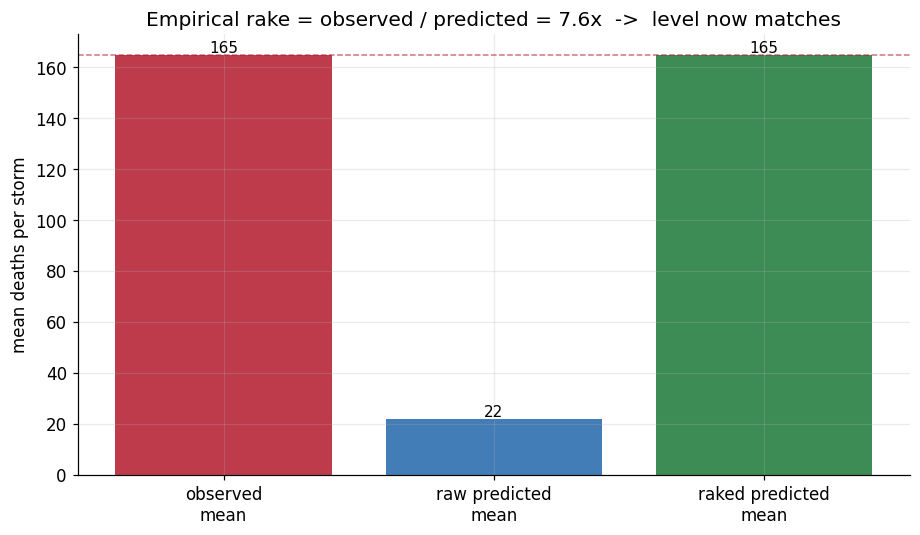

Reference-window observed mean :    164.6
Reference-window predicted mean:     21.7
Rake factor                    :     7.58x
Raked predicted mean           :    164.6  (matches observed by construction)


In [8]:
ref_obs_mean  = deaths_rec.mean()
ref_pred_mean = predict_mean(x_rec, coef_rec, smear_rec).mean()
rake = ref_obs_mean / ref_pred_mean

raked_mean = ref_pred_mean * rake

fig, ax = plt.subplots()
labels = ["observed\nmean", "raw predicted\nmean", "raked predicted\nmean"]
vals   = [ref_obs_mean, ref_pred_mean, raked_mean]
cols   = [C_OBS, C_MODEL, C_FIX]
ax.bar(labels, vals, color=cols, alpha=0.85)
ax.axhline(ref_obs_mean, color=C_OBS, lw=1, ls="--", alpha=0.6)
for i, v in enumerate(vals):
    ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("mean deaths per storm")
ax.set_title(f"Empirical rake = observed / predicted = {rake:.1f}x  ->  level now matches")
plt.tight_layout()
plt.show()

print(f"Reference-window observed mean : {ref_obs_mean:8.1f}")
print(f"Reference-window predicted mean: {ref_pred_mean:8.1f}")
print(f"Rake factor                    : {rake:8.2f}x")
print(f"Raked predicted mean           : {raked_mean:8.1f}  (matches observed by construction)")

**Takeaway (after):** The rake snaps the predicted *level* onto the observed level.
But note what it did **not** do: it multiplied *every* storm by the same factor, so it still
does not predict which storm is the catastrophe or how big it is — it just spreads the
average historical catastrophe burden across the projection.

**The key assumption, stated explicitly:** the rake ratio is assumed **stable and
transportable** — that the ratio of observed-to-predicted over the reference window will hold
in the projection window. If future catastrophe frequency or severity differs from the
reference period (climate change, exposure growth, a period with no mega-event, or one with
several), the rake will be systematically off. That assumption is doing real work and should
be revisited when the reference window changes.

## So what — mapping the toy back to the TC-mortality pipeline

| Toy element | Pipeline analogue |
|---|---|
| covariate $x$ (wind analogue) | wind speed, SDI, basin, island flag |
| bulk lognormal, fit below threshold | the **bulk** rate regression (`rate < threshold`), under stages 1–2 hurdles |
| Pareto catastrophes, $\perp x$ | the **tail** model (GPD / log-logistic / Weibull) region; real mega-event tolls are governance / storm-surge / warning-failure specific, *not* a function of wind |
| deaths as the outcome | `deaths = predicted_rate × exposure` — the exposure multiply doesn't change the logic; a central *rate* back-transformed and scaled still targets the median, so both mechanisms carry straight through |
| smearing correction (Fig 3) | **Mechanism 1**: retransformation bias from predicting on the log scale. Real but modest; a correction closes it. |
| surviving gap after smearing | **Mechanism 2**: the unmodelled catastrophe burden. Dominant, and not fixable by the model. |
| CV collapse of catastrophes (Fig 5) | why **in-sample ≈ OOS** and both under-predict: the held-out mega-event can't be memorised. Toy Nargis under-predicted ~100s×; real **Nargis 2008: ~140,500 observed vs ~1,200 predicted**. |
| window-mean skew (Fig 4) | why the observed **24-year mean** (2000–2023) sits above the model's stable expectation — one catastrophe dominates the window |
| the rake (Fig 6) | the per-super-region multiplicative **rake** = observed mean / predicted mean over a reference window |

**Bottom line:**

1. The under-prediction is **expected behaviour of a calibrated central-tendency model on a
   heavy-tailed outcome — not a bug and not a fit failure.** In ordinary years the model
   tracks observed within ~2×; in-sample and OOS coincide. The mega-event shortfall is
   structural.
2. **Two distinct mechanisms**, kept separate: (1) retransformation/Jensen bias — modest,
   fixable by a smearing/analytic correction; (2) heavy-tail unpredictability — dominant,
   *not* fixable, because catastrophe magnitude is not a function of the covariates and the
   sample mean is dominated by the largest realisation.
3. The empirical rake fixes the **level** by transferring the average historical catastrophe
   burden onto the projection. It does **not** make the model predict individual
   catastrophes, and it rests on the ratio being **stable / transportable** to the future.